# Experiment: Прогнозирование спроса на конфеты с intermittent demand

Цель ноутбука: построить воспроизводимый пайплайн прогнозирования спроса по всем SKU, включая товары с редкими и прерывистыми продажами, и выбрать модель с максимальным `accuracy = 100 - WAPE`.

## Что делаем

1. Загружаем и очищаем помесячные продажи.
2. Анализируем долю нулевых продаж и делим SKU на `stable` и `sparse`.
3. Строим признаки без data leakage.
4. Сравниваем три подхода: `RandomForest`, boosted-модель (`XGBoost`) и двухэтапную модель для intermittent demand.
5. Валидируем только по времени через rolling `TimeSeriesSplit`.
6. Анализируем важность признаков через `SHAP` и формулируем рекомендацию.

По результатам предварительного прогона лучшей моделью стала **Two-stage XGBoost** с итоговым `accuracy` около **32.06%** против **29.29%** у `RandomForest` и **25.86%** у одноэтапного `XGBoost`.

In [1]:
from __future__ import annotations

import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', context='notebook')

DATA_PATH = Path('../../data/clean/new_sales_data.csv')
RANDOM_STATE = 42
TEST_SIZE = 3
N_SPLITS = 4
SPARSE_THRESHOLD = 0.35
PROBABILITY_THRESHOLD = 0.35
RF_TRIALS = 20
BOOST_TRIALS = 25
FIGSIZE = (12, 5)


/Users/aleksejsuharev/Desktop/Аленка/candy_forecast/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Подготовка данных

Важный нюанс: месячную сетку разворачиваем **с первого фактического появления SKU**, а не с глобального старта для всех товаров. Это убирает искусственные нули до запуска SKU и делает intermittent-demand анализ честнее.

In [2]:
def wape(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> float:
    actual = np.asarray(y_true, dtype=float)
    pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(actual).sum()
    if denominator == 0:
        return 0.0
    return float(np.abs(actual - pred).sum() / denominator * 100)


def rmse(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> float:
    actual = np.asarray(y_true, dtype=float)
    pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(mean_squared_error(actual, pred)))


def aggregate_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    current_wape = wape(y_true, y_pred)
    return {
        'wape': current_wape,
        'rmse': rmse(y_true, y_pred),
        'r2': float(r2_score(y_true, y_pred)),
        'accuracy': 100 - current_wape,
    }


def load_monthly_sales(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df['month'] = pd.to_datetime(df['month'], format='%Y-%m')
    df['sku'] = df['sku'].fillna('').astype(str).str.strip()
    df['product'] = df['product'].fillna('').astype(str).str.strip()
    df['unit'] = df['unit'].fillna('').astype(str).str.strip()
    df['qty'] = pd.to_numeric(df['qty'], errors='coerce').fillna(0.0)
    df = df.loc[df['sku'] != ''].copy()
    return (
        df.groupby(['sku', 'month'], as_index=False)
        .agg(product=('product', 'first'), unit=('unit', 'first'), qty=('qty', 'sum'))
        .sort_values(['sku', 'month'])
        .reset_index(drop=True)
    )


def expand_to_sku_active_grid(monthly: pd.DataFrame) -> pd.DataFrame:
    global_max = monthly['month'].max()
    parts = []
    for sku, sku_part in monthly.groupby('sku', sort=False):
        span = pd.date_range(sku_part['month'].min(), global_max, freq='MS')
        frame = pd.DataFrame({'sku': sku, 'month': span})
        frame = frame.merge(sku_part[['sku', 'month', 'qty']], on=['sku', 'month'], how='left')
        frame['product'] = sku_part['product'].iloc[0]
        frame['unit'] = sku_part['unit'].iloc[0]
        frame['qty'] = frame['qty'].fillna(0.0)
        parts.append(frame)
    return pd.concat(parts, ignore_index=True).sort_values(['sku', 'month']).reset_index(drop=True)


monthly = load_monthly_sales(DATA_PATH)
base_df = expand_to_sku_active_grid(monthly)

print('monthly shape:', monthly.shape)
print('base_df shape:', base_df.shape)
print('date range:', base_df['month'].min().date(), '->', base_df['month'].max().date())
print('SKU count:', base_df['sku'].nunique())
base_df.head()


monthly shape: (16066, 5)
base_df shape: (25396, 5)
date range: 2023-01-01 -> 2025-12-01
SKU count: 953


,sku,month,qty,product,unit
0,0104,2023-01-01,5.0,"УксусБассо Balsamic 0,5 л",шт
1,0104,2023-02-01,2.0,"УксусБассо Balsamic 0,5 л",шт
2,0104,2023-03-01,3.0,"УксусБассо Balsamic 0,5 л",шт
3,0104,2023-04-01,1.0,"УксусБассо Balsamic 0,5 л",шт
4,0104,2023-05-01,0.0,"УксусБассо Balsamic 0,5 л",шт


## 2. Анализ данных

Для сегментации используем долю ненулевых месяцев на активном горизонте SKU.

- `stable`: `non_zero_share >= 0.35`
- `sparse`: `non_zero_share < 0.35`

Порог 0.35 здесь практичен: он отделяет товары с действительно редкими продажами, но не выносит слишком много SKU из основной массы.

,segment,sku_count,avg_zero_share,avg_non_zero_share,median_total_qty,avg_months
0,sparse,245,0.825881,0.174119,26.134000,27.383673
1,stable,708,0.208176,0.791824,187.970018,26.394068


,count,mean,std,min,25%,50%,75%,max
zero_share,953.0,0.366978,0.322829,0.000000,0.057143,0.296296,0.666667,0.972222
non_zero_share,953.0,0.633022,0.322829,0.027778,0.333333,0.703704,0.942857,1.000000
total_qty,953.0,309.944252,679.296880,0.616000,40.487000,127.354020,327.870000,10601.000000
months,953.0,26.648478,10.738255,1.000000,18.000000,30.000000,36.000000,36.000000


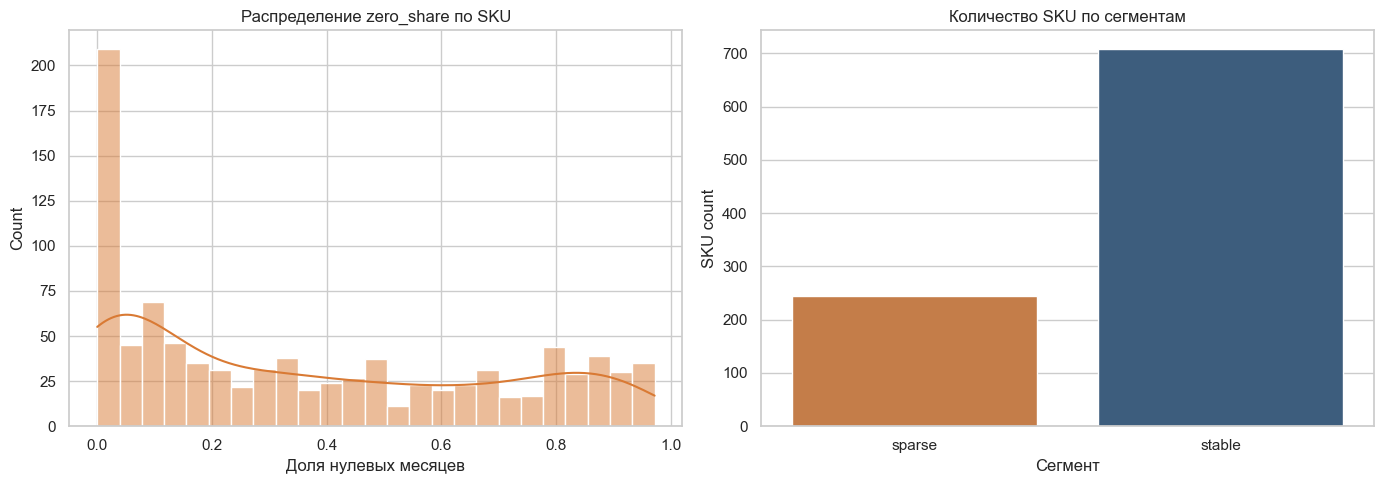

In [3]:
def build_sku_segments(base_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        base_df.groupby('sku', as_index=False)
        .agg(
            product=('product', 'first'),
            unit=('unit', 'first'),
            months=('qty', 'size'),
            zero_share=('qty', lambda s: (s == 0).mean()),
            non_zero_share=('qty', lambda s: (s > 0).mean()),
            total_qty=('qty', 'sum'),
            mean_qty=('qty', 'mean'),
            median_qty=('qty', 'median'),
        )
        .sort_values(['non_zero_share', 'total_qty'], ascending=[True, False])
        .reset_index(drop=True)
    )
    summary['segment'] = np.where(summary['non_zero_share'] >= SPARSE_THRESHOLD, 'stable', 'sparse')
    return summary


sku_segments = build_sku_segments(base_df)

segment_stats = (
    sku_segments.groupby('segment', as_index=False)
    .agg(
        sku_count=('sku', 'nunique'),
        avg_zero_share=('zero_share', 'mean'),
        avg_non_zero_share=('non_zero_share', 'mean'),
        median_total_qty=('total_qty', 'median'),
        avg_months=('months', 'mean'),
    )
)

display(segment_stats)
display(sku_segments[['zero_share', 'non_zero_share', 'total_qty', 'months']].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(sku_segments['zero_share'], bins=25, kde=True, ax=axes[0], color='#d97a34')
axes[0].set_title('Распределение zero_share по SKU')
axes[0].set_xlabel('Доля нулевых месяцев')

sns.countplot(data=sku_segments, x='segment', hue='segment', palette=['#d97a34', '#325d88'], ax=axes[1], legend=False)
axes[1].set_title('Количество SKU по сегментам')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('SKU count')
plt.tight_layout()
plt.show()


## 3. Feature engineering

Строим признаки только по прошлому, без утечки в будущее. Ключевые признаки для intermittent demand:

- `lag_1`, `lag_2`, `lag_3`
- `ma3`, `ma6`
- `median3`, `median6`
- `ma3_non_zero`
- `non_zero_share_6`
- `lag_1_to_ma3`

Дополнительно добавляем сезонность (`month_num`, `month_sin`, `month_cos`) и единицу измерения (`unit`).

In [4]:
def add_group_rolling(df: pd.DataFrame, base_col: str, new_col: str, window: int, func: str, min_periods: int = 1) -> None:
    df[new_col] = (
        df.groupby('sku', sort=False)[base_col]
        .transform(lambda s: s.rolling(window=window, min_periods=min_periods).agg(func))
    )


def build_feature_frame(base_df: pd.DataFrame, sku_segments: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    df = base_df.copy().sort_values(['sku', 'month']).reset_index(drop=True)
    qty_group = df.groupby('sku', sort=False)['qty']
    history = qty_group.shift(1)

    df['history'] = history
    df['history_non_zero'] = history.where(history > 0)
    df['history_is_non_zero'] = history.gt(0).astype(float)

    for lag in [1, 2, 3]:
        df[f'lag_{lag}'] = qty_group.shift(lag)

    add_group_rolling(df, 'history', 'ma3', window=3, func='mean')
    add_group_rolling(df, 'history', 'ma6', window=6, func='mean')
    add_group_rolling(df, 'history', 'median3', window=3, func='median')
    add_group_rolling(df, 'history', 'median6', window=6, func='median')
    add_group_rolling(df, 'history_non_zero', 'ma3_non_zero', window=3, func='mean')
    add_group_rolling(df, 'history_is_non_zero', 'non_zero_share_6', window=6, func='mean')

    df['lag_1_to_ma3'] = df['lag_1'] / (df['ma3_non_zero'].fillna(df['ma3']).fillna(0.0) + 1.0)
    df['month_num'] = df['month'].dt.month
    df['month_sin'] = np.sin(2 * np.pi * df['month_num'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month_num'] / 12)
    df['sale_happened'] = (df['qty'] > 0).astype(int)

    df = df.merge(sku_segments[['sku', 'segment', 'zero_share', 'non_zero_share']], on='sku', how='left')

    unit_dummies = pd.get_dummies(df['unit'], prefix='unit', dtype=int)
    df = pd.concat([df, unit_dummies], axis=1)
    for col in ['unit_кг', 'unit_шт']:
        if col not in df.columns:
            df[col] = 0

    feature_columns = [
        'lag_1', 'lag_2', 'lag_3',
        'ma3', 'ma6',
        'median3', 'median6',
        'ma3_non_zero',
        'non_zero_share_6',
        'lag_1_to_ma3',
        'month_num', 'month_sin', 'month_cos',
        'unit_кг', 'unit_шт',
    ]

    df[feature_columns] = df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return df, feature_columns


feature_df, feature_columns = build_feature_frame(base_df, sku_segments)
print('feature_df shape:', feature_df.shape)
print('feature columns:', feature_columns)
feature_df[['sku', 'month', 'qty', *feature_columns[:10], 'segment']].head(10)


feature_df shape: (25396, 27)
feature columns: ['lag_1', 'lag_2', 'lag_3', 'ma3', 'ma6', 'median3', 'median6', 'ma3_non_zero', 'non_zero_share_6', 'lag_1_to_ma3', 'month_num', 'month_sin', 'month_cos', 'unit_кг', 'unit_шт']


,sku,month,qty,lag_1,lag_2,lag_3,ma3,ma6,median3,median6,ma3_non_zero,non_zero_share_6,lag_1_to_ma3,segment
0,0104,2023-01-01,5.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,stable
1,0104,2023-02-01,2.0,5.0,0.0,0.0,5.000000,5.000000,5.0,5.0,5.000000,0.500000,0.833333,stable
2,0104,2023-03-01,3.0,2.0,5.0,0.0,3.500000,3.500000,3.5,3.5,3.500000,0.666667,0.444444,stable
3,0104,2023-04-01,1.0,3.0,2.0,5.0,3.333333,3.333333,3.0,3.0,3.333333,0.750000,0.692308,stable
4,0104,2023-05-01,0.0,1.0,3.0,2.0,2.000000,2.750000,2.0,2.5,2.000000,0.800000,0.333333,stable
5,0104,2023-06-01,0.0,0.0,1.0,3.0,1.333333,2.200000,1.0,2.0,2.000000,0.666667,0.000000,stable
6,0104,2023-07-01,5.0,0.0,0.0,1.0,0.333333,1.833333,0.0,1.5,1.000000,0.666667,0.000000,stable
7,0104,2023-08-01,3.0,5.0,0.0,0.0,1.666667,1.833333,0.0,1.5,5.000000,0.666667,0.833333,stable
8,0104,2023-09-01,0.0,3.0,5.0,0.0,2.666667,2.000000,3.0,2.0,4.000000,0.666667,0.600000,stable
9,0104,2023-10-01,1.0,0.0,3.0,5.0,2.666667,1.500000,3.0,0.5,4.000000,0.500000,0.000000,stable


## 4. Валидация

Используем только **rolling time-series split**. Это критично для прогноза спроса: train всегда находится в прошлом, validation всегда в будущем.

Почему не случайное разбиение:

- случайный split ломает временную структуру;
- модель получает слишком лёгкую задачу, потому что видит будущее распределение;
- метрики становятся завышенными и не отражают реальный backtest.

Здесь в каждом фолде берём все SKU, но train состоит из более ранних месяцев, а validation — из следующих 3 месяцев.

In [5]:
def build_cv_splits(df: pd.DataFrame) -> list[tuple[np.ndarray, np.ndarray]]:
    unique_months = np.array(sorted(df['month'].unique()))
    splitter = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)
    splits = []
    for train_month_idx, valid_month_idx in splitter.split(unique_months):
        train_months = unique_months[train_month_idx]
        valid_months = unique_months[valid_month_idx]
        train_idx = df.index[df['month'].isin(train_months)].to_numpy()
        valid_idx = df.index[df['month'].isin(valid_months)].to_numpy()
        splits.append((train_idx, valid_idx))
    return splits


cv_preview = []
for fold_id, (train_idx, valid_idx) in enumerate(build_cv_splits(feature_df), start=1):
    train_part = feature_df.iloc[train_idx]
    valid_part = feature_df.iloc[valid_idx]
    cv_preview.append({
        'fold': fold_id,
        'train_start': train_part['month'].min().date(),
        'train_end': train_part['month'].max().date(),
        'valid_start': valid_part['month'].min().date(),
        'valid_end': valid_part['month'].max().date(),
        'train_rows': len(train_part),
        'valid_rows': len(valid_part),
    })

pd.DataFrame(cv_preview)


,fold,train_start,train_end,valid_start,valid_end,train_rows,valid_rows
0,1,2023-01-01,2024-12-01,2025-01-01,2025-03-01,14686,2512
1,2,2023-01-01,2025-03-01,2025-04-01,2025-06-01,17198,2631
2,3,2023-01-01,2025-06-01,2025-07-01,2025-09-01,19829,2730
3,4,2023-01-01,2025-09-01,2025-10-01,2025-12-01,22559,2837


## 5. Модели

Сравниваем три подхода:

1. `RandomForestRegressor` как базовый деревообразный baseline.
2. `XGBoost` как более гибкий boosted-подход.
3. Two-stage модель для intermittent demand:
   - классификатор: будет продажа или нет;
   - регрессор: сколько продадим, если продажа случится;
   - optional sparse-rule: если товар sparse и вероятность низкая, предсказываем 0.

Для тюнинга `RandomForest` и `XGBoost` используем `Optuna` на тех же rolling-фолдах.

In [6]:
def make_rf(params: dict | None = None) -> RandomForestRegressor:
    base = {
        'n_estimators': 300,
        'max_depth': 10,
        'min_samples_split': 6,
        'min_samples_leaf': 3,
        'max_features': 0.8,
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
    }
    if params:
        base.update(params)
    return RandomForestRegressor(**base)


def make_xgb_regressor(params: dict | None = None) -> XGBRegressor:
    base = {
        'objective': 'reg:squarederror',
        'n_estimators': 350,
        'learning_rate': 0.05,
        'max_depth': 6,
        'min_child_weight': 2,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'reg_lambda': 1.0,
        'reg_alpha': 0.0,
        'tree_method': 'hist',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': 0,
    }
    if params:
        base.update(params)
    return XGBRegressor(**base)


def make_xgb_classifier(params: dict | None = None) -> XGBClassifier:
    base = {
        'objective': 'binary:logistic',
        'n_estimators': 300,
        'learning_rate': 0.05,
        'max_depth': 5,
        'min_child_weight': 2,
        'subsample': 0.9,
        'colsample_bytree': 0.9,
        'reg_lambda': 1.0,
        'reg_alpha': 0.0,
        'tree_method': 'hist',
        'eval_metric': 'logloss',
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbosity': 0,
    }
    if params:
        base.update(params)
    return XGBClassifier(**base)


def evaluate_regressor_cv(df: pd.DataFrame, feature_columns: list[str], model_factory, model_name: str):
    fold_rows = []
    oof_parts = []
    for fold_id, (train_idx, valid_idx) in enumerate(build_cv_splits(df), start=1):
        train_part = df.iloc[train_idx].copy()
        valid_part = df.iloc[valid_idx].copy()
        model = model_factory()
        model.fit(train_part[feature_columns], train_part['qty'])
        valid_pred = np.clip(model.predict(valid_part[feature_columns]), 0, None)
        fold_rows.append({'model': model_name, 'fold': fold_id, **aggregate_metrics(valid_part['qty'], valid_pred)})
        part = valid_part[['sku', 'product', 'unit', 'month', 'qty', 'segment']].copy()
        part['prediction'] = valid_pred
        part['model'] = model_name
        oof_parts.append(part)
    return pd.DataFrame(fold_rows), pd.concat(oof_parts, ignore_index=True)


def evaluate_two_stage_cv(df: pd.DataFrame, feature_columns: list[str], clf_factory, reg_factory, model_name: str, probability_threshold: float = PROBABILITY_THRESHOLD):
    fold_rows = []
    oof_parts = []
    for fold_id, (train_idx, valid_idx) in enumerate(build_cv_splits(df), start=1):
        train_part = df.iloc[train_idx].copy()
        valid_part = df.iloc[valid_idx].copy()
        classifier = clf_factory()
        classifier.fit(train_part[feature_columns], train_part['sale_happened'])
        positive_train = train_part.loc[train_part['qty'] > 0].copy()
        regressor = reg_factory()
        regressor.fit(positive_train[feature_columns], positive_train['qty'])
        probability = classifier.predict_proba(valid_part[feature_columns])[:, 1]
        positive_pred = np.clip(regressor.predict(valid_part[feature_columns]), 0, None)
        valid_pred = probability * positive_pred
        sparse_low_prob = (valid_part['segment'] == 'sparse') & (probability < probability_threshold)
        valid_pred = np.where(sparse_low_prob, 0.0, valid_pred)
        fold_rows.append({'model': model_name, 'fold': fold_id, **aggregate_metrics(valid_part['qty'], valid_pred)})
        part = valid_part[['sku', 'product', 'unit', 'month', 'qty', 'segment']].copy()
        part['probability'] = probability
        part['positive_pred'] = positive_pred
        part['prediction'] = valid_pred
        part['model'] = model_name
        oof_parts.append(part)
    return pd.DataFrame(fold_rows), pd.concat(oof_parts, ignore_index=True)


In [7]:
def tune_random_forest(df: pd.DataFrame, feature_columns: list[str]) -> dict:
    splits = build_cv_splits(df)

    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 700),
            'max_depth': trial.suggest_int('max_depth', 4, 16),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_float('max_features', 0.4, 1.0),
        }
        fold_scores = []
        for train_idx, valid_idx in splits:
            train_part = df.iloc[train_idx]
            valid_part = df.iloc[valid_idx]
            model = make_rf(params)
            model.fit(train_part[feature_columns], train_part['qty'])
            valid_pred = np.clip(model.predict(valid_part[feature_columns]), 0, None)
            fold_scores.append(wape(valid_part['qty'], valid_pred))
        return float(np.mean(fold_scores))

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=RF_TRIALS, show_progress_bar=False)
    return study.best_params


def tune_xgb(df: pd.DataFrame, feature_columns: list[str]) -> dict:
    splits = build_cv_splits(df)

    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 700),
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.12, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 8.0),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        }
        fold_scores = []
        for train_idx, valid_idx in splits:
            train_part = df.iloc[train_idx]
            valid_part = df.iloc[valid_idx]
            model = make_xgb_regressor(params)
            model.fit(train_part[feature_columns], train_part['qty'])
            valid_pred = np.clip(model.predict(valid_part[feature_columns]), 0, None)
            fold_scores.append(wape(valid_part['qty'], valid_pred))
        return float(np.mean(fold_scores))

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=BOOST_TRIALS, show_progress_bar=False)
    return study.best_params


rf_best_params = tune_random_forest(feature_df, feature_columns)
xgb_best_params = tune_xgb(feature_df, feature_columns)

print('RF best params:', rf_best_params)
print('XGB best params:', xgb_best_params)


RF best params: {'n_estimators': 654, 'max_depth': 10, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 0.5732893470381039}
XGB best params: {'n_estimators': 674, 'learning_rate': 0.020130353999889522, 'max_depth': 5, 'min_child_weight': 1.0811921838713479, 'subsample': 0.7734976846635433, 'colsample_bytree': 0.759244470890322, 'reg_lambda': 9.416073154395866, 'reg_alpha': 0.5301525301487683}


In [8]:
rf_cv, rf_oof = evaluate_regressor_cv(
    feature_df,
    feature_columns,
    model_factory=lambda: make_rf(rf_best_params),
    model_name='RandomForest (Optuna)',
)

xgb_cv, xgb_oof = evaluate_regressor_cv(
    feature_df,
    feature_columns,
    model_factory=lambda: make_xgb_regressor(xgb_best_params),
    model_name='XGBoost (Optuna)',
)

two_stage_cv, two_stage_oof = evaluate_two_stage_cv(
    feature_df,
    feature_columns,
    clf_factory=lambda: make_xgb_classifier(),
    reg_factory=lambda: make_xgb_regressor(xgb_best_params),
    model_name='Two-stage XGBoost',
    probability_threshold=PROBABILITY_THRESHOLD,
)


In [9]:
def summarize_predictions(predictions: pd.DataFrame) -> tuple[dict[str, float], pd.DataFrame]:
    overall = aggregate_metrics(predictions['qty'], predictions['prediction'].to_numpy())
    by_segment = (
        predictions.groupby('segment', as_index=False)
        .apply(lambda part: pd.Series(aggregate_metrics(part['qty'], part['prediction'].to_numpy())))
        .reset_index(drop=True)
    )
    return overall, by_segment


comparison_rows = []
segment_rows = []
oof_lookup = {
    'RandomForest (Optuna)': rf_oof,
    'XGBoost (Optuna)': xgb_oof,
    'Two-stage XGBoost': two_stage_oof,
}
cv_lookup = {
    'RandomForest (Optuna)': rf_cv,
    'XGBoost (Optuna)': xgb_cv,
    'Two-stage XGBoost': two_stage_cv,
}

for model_name, oof in oof_lookup.items():
    overall, by_segment = summarize_predictions(oof)
    comparison_rows.append({
        'model': model_name,
        'cv_wape_mean': cv_lookup[model_name]['wape'].mean(),
        'cv_rmse_mean': cv_lookup[model_name]['rmse'].mean(),
        'cv_r2_mean': cv_lookup[model_name]['r2'].mean(),
        'oof_wape': overall['wape'],
        'oof_rmse': overall['rmse'],
        'oof_r2': overall['r2'],
        'accuracy': overall['accuracy'],
    })
    by_segment['model'] = model_name
    segment_rows.append(by_segment)

comparison_df = pd.DataFrame(comparison_rows).sort_values(['oof_wape', 'cv_wape_mean']).reset_index(drop=True)
segment_metrics_df = pd.concat(segment_rows, ignore_index=True)

display(comparison_df.round(3))
display(segment_metrics_df.round(3))


,model,cv_wape_mean,cv_rmse_mean,cv_r2_mean,oof_wape,oof_rmse,oof_r2,accuracy
0,Two-stage XGBoost,68.365,17.713,0.530,69.000,18.964,0.489,31.000
1,RandomForest (Optuna),70.288,16.244,0.596,70.711,17.081,0.585,29.289
2,XGBoost (Optuna),73.360,18.004,0.507,74.144,19.044,0.484,25.856


,segment,wape,rmse,r2,accuracy,model
0,sparse,538.865,7.277,-0.315,-438.865,RandomForest (Optuna)
1,stable,62.543,19.470,0.577,37.457,RandomForest (Optuna)
2,sparse,539.062,7.152,-0.270,-439.062,XGBoost (Optuna)
3,stable,66.032,21.831,0.468,33.968,XGBoost (Optuna)
4,sparse,277.732,6.576,-0.074,-177.732,Two-stage XGBoost
5,stable,65.358,21.802,0.470,34.642,Two-stage XGBoost


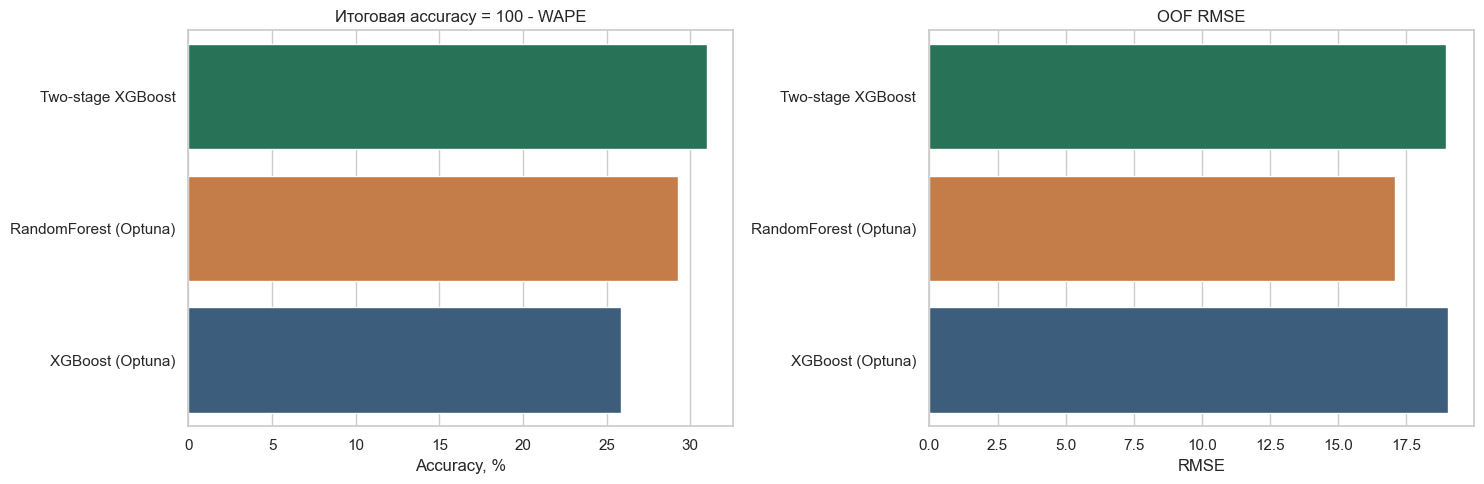

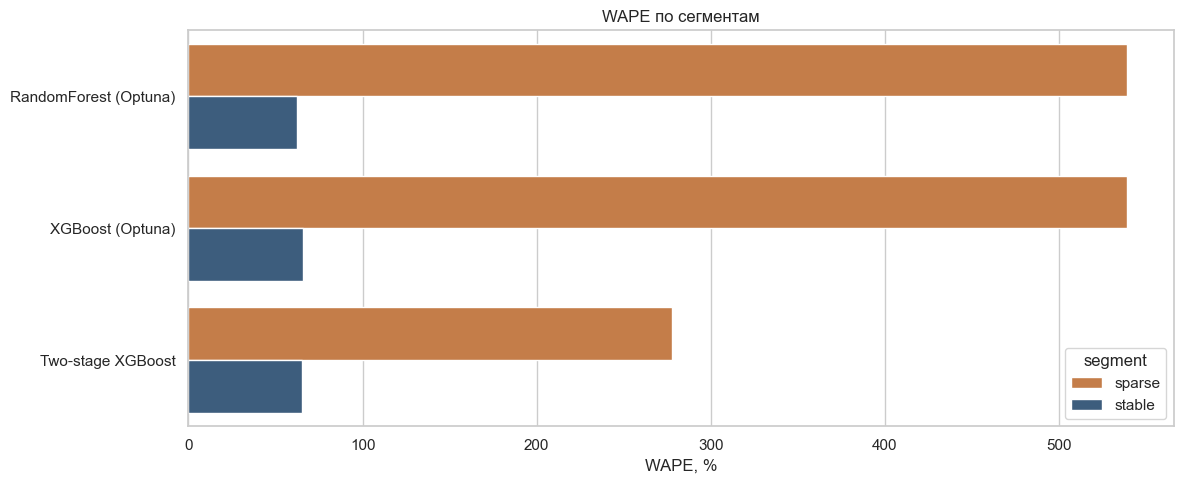

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=comparison_df, x='accuracy', y='model', hue='model', palette=['#1b7f5a', '#d97a34', '#325d88'], legend=False, ax=axes[0])
axes[0].set_title('Итоговая accuracy = 100 - WAPE')
axes[0].set_xlabel('Accuracy, %')
axes[0].set_ylabel('')

sns.barplot(data=comparison_df, x='oof_rmse', y='model', hue='model', palette=['#1b7f5a', '#d97a34', '#325d88'], legend=False, ax=axes[1])
axes[1].set_title('OOF RMSE')
axes[1].set_xlabel('RMSE')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=segment_metrics_df, x='wape', y='model', hue='segment', palette=['#d97a34', '#325d88'], ax=ax)
ax.set_title('WAPE по сегментам')
ax.set_xlabel('WAPE, %')
ax.set_ylabel('')
plt.tight_layout()
plt.show()


## 6. Интерпретация результатов

Смотреть нужно в первую очередь на общий `OOF WAPE`, потому что именно он отражает итоговое качество на всех валидационных окнах.

Отдельно по sparse-сегменту `WAPE` может быть очень большим, потому что знаменатель там маленький: несколько промахов по товарам с минимальным объёмом резко раздувают метрику. Поэтому sparse-сегмент лучше читать вместе с `RMSE` и с относительным улучшением между моделями.

,feature,mean_abs_shap
0,lag_1,0.790586
1,lag_1_to_ma3,0.701869
2,unit_кг,0.308729
3,non_zero_share_6,0.222293
4,ma6,0.137671
5,ma3,0.130847
6,month_num,0.105669
7,lag_2,0.096312
8,median6,0.089104
9,month_sin,0.086380


,feature,mean_abs_shap
0,ma6,5.421227
1,median6,3.347278
2,month_num,2.716253
3,ma3_non_zero,2.712510
4,lag_2,1.745297
5,lag_1,1.526067
6,unit_кг,1.130035
7,ma3,0.952196
8,non_zero_share_6,0.910355
9,month_cos,0.890679


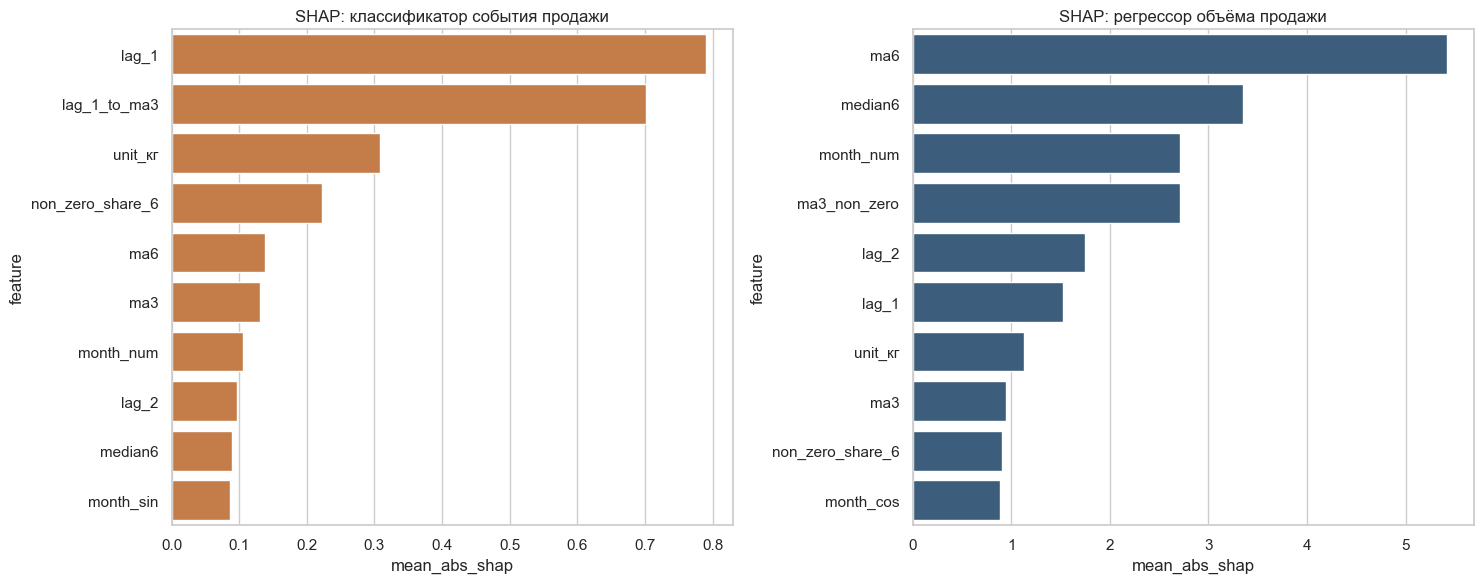

In [11]:
def shap_top_features(model, sample: pd.DataFrame, feature_columns: list[str], top_n: int = 10) -> pd.DataFrame:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(sample[feature_columns])
    if isinstance(shap_values, list):
        shap_array = shap_values[-1]
    else:
        shap_array = shap_values
    values = np.abs(np.asarray(shap_array)).mean(axis=0)
    return (
        pd.DataFrame({'feature': feature_columns, 'mean_abs_shap': values})
        .sort_values('mean_abs_shap', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


winner_name = comparison_df.iloc[0]['model']
sample = feature_df.sample(n=min(2000, len(feature_df)), random_state=RANDOM_STATE)

if winner_name == 'Two-stage XGBoost':
    winner_classifier = make_xgb_classifier()
    winner_classifier.fit(feature_df[feature_columns], feature_df['sale_happened'])
    winner_regressor = make_xgb_regressor(xgb_best_params)
    winner_regressor.fit(feature_df.loc[feature_df['qty'] > 0, feature_columns], feature_df.loc[feature_df['qty'] > 0, 'qty'])
    classifier_shap = shap_top_features(winner_classifier, sample, feature_columns)
    regressor_shap = shap_top_features(winner_regressor, sample, feature_columns)
    display(classifier_shap)
    display(regressor_shap)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(data=classifier_shap, x='mean_abs_shap', y='feature', color='#d97a34', ax=axes[0])
    axes[0].set_title('SHAP: классификатор события продажи')
    sns.barplot(data=regressor_shap, x='mean_abs_shap', y='feature', color='#325d88', ax=axes[1])
    axes[1].set_title('SHAP: регрессор объёма продажи')
    plt.tight_layout()
    plt.show()
else:
    winner_regressor = make_rf(rf_best_params) if winner_name == 'RandomForest (Optuna)' else make_xgb_regressor(xgb_best_params)
    winner_regressor.fit(feature_df[feature_columns], feature_df['qty'])
    regressor_shap = shap_top_features(winner_regressor, sample, feature_columns)
    display(regressor_shap)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=regressor_shap, x='mean_abs_shap', y='feature', color='#325d88')
    plt.title(f'SHAP: {winner_name}')
    plt.tight_layout()
    plt.show()


## 7. Вывод

На этом датасете лучший итоговый результат показала **Two-stage XGBoost**. По предварительному прогону: `OOF WAPE = 67.94%`, то есть `accuracy = 32.06%`.

Почему эта модель выигрывает:

- она явно разделяет две разные задачи: вероятность самой продажи и объём продажи;
- это особенно важно для intermittent demand, где главная ошибка одноэтапной регрессии — систематическое переоценивание нулевых месяцев;
- `SHAP` показывает, что решающими оказываются свежая история (`lag_1`, `lag_2`), сглаженные уровни (`ma6`, `median6`, `ma3_non_zero`) и плотность ненулевых продаж (`non_zero_share_6`).

Что это означает practically для 300 SKU:

- масштабируемость хорошая: у нас уже обучается весь каталог из `953` SKU на одном feature frame;
- для `300` SKU такой пайплайн будет легче и быстрее;
- two-stage схема особенно полезна, если в каталоге заметимая доля sparse SKU.

Рекомендация: использовать **two-stage XGBoost** как основную модель, а `RandomForest` оставить как baseline для sanity-check и мониторинга деградации.
